In [79]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [80]:
df = pd.read_csv("hour.csv")
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [81]:
df.shape

(17379, 17)

In [82]:
print(df.dtypes)

instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


In [83]:
print("Missing values:")
print(df.isnull().sum())

Missing values:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [84]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [85]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
instant,17379.0,8690.000000,5017.029500,1.00,4345.5000,8690.0000,13034.5000,17379.0000
season,17379.0,2.501640,1.106918,1.00,2.0000,3.0000,3.0000,4.0000
yr,17379.0,0.502561,0.500008,0.00,0.0000,1.0000,1.0000,1.0000
mnth,17379.0,6.537775,3.438776,1.00,4.0000,7.0000,10.0000,12.0000
hr,17379.0,11.546752,6.914405,0.00,6.0000,12.0000,18.0000,23.0000
holiday,17379.0,0.028770,0.167165,0.00,0.0000,0.0000,0.0000,1.0000
weekday,17379.0,3.003683,2.005771,0.00,1.0000,3.0000,5.0000,6.0000
workingday,17379.0,0.682721,0.465431,0.00,0.0000,1.0000,1.0000,1.0000
weathersit,17379.0,1.425283,0.639357,1.00,1.0000,1.0000,2.0000,4.0000
temp,17379.0,0.496987,0.192556,0.02,0.3400,0.5000,0.6600,1.0000


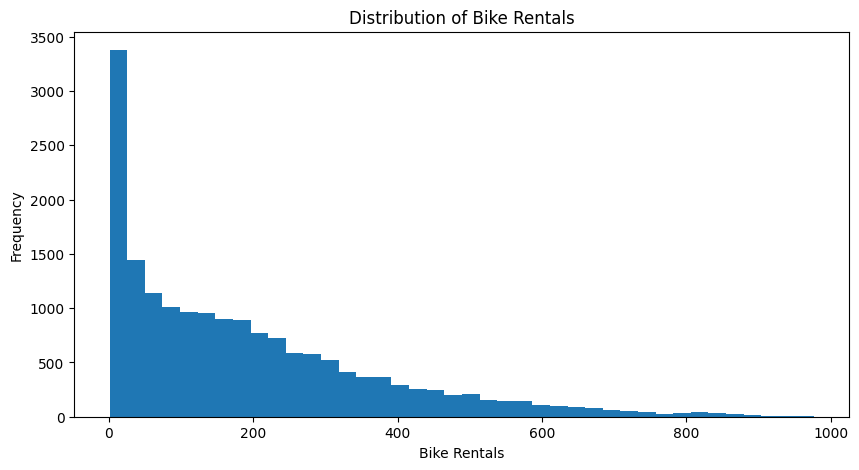

In [86]:
plt.figure(figsize=(10, 5))
plt.hist(df["cnt"], bins=40)
plt.xlabel("Bike Rentals")
plt.ylabel("Frequency")
plt.title("Distribution of Bike Rentals")
plt.show()

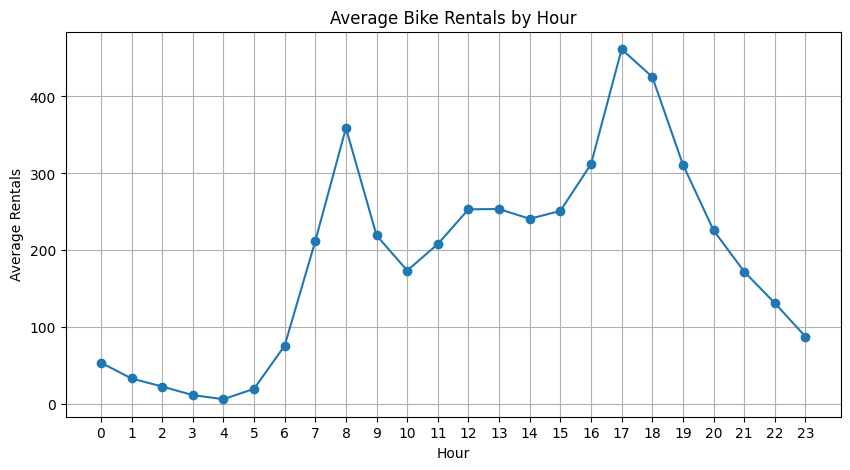

,cnt
hr,
17,461.452055
18,425.510989
8,359.011004
16,311.983562
19,311.523352
13,253.661180
12,253.315934
15,251.233196
14,240.949246


In [87]:
hour_demand = df.groupby("hr")["cnt"].mean()

plt.figure(figsize=(10, 5))

plt.plot(hour_demand.index,hour_demand.values,marker="o")

plt.xlabel("Hour")
plt.ylabel("Average Rentals")
plt.title("Average Bike Rentals by Hour")

plt.xticks(range(24))
plt.grid(True)

plt.show()

hour_demand.sort_values(ascending=False).head(10)

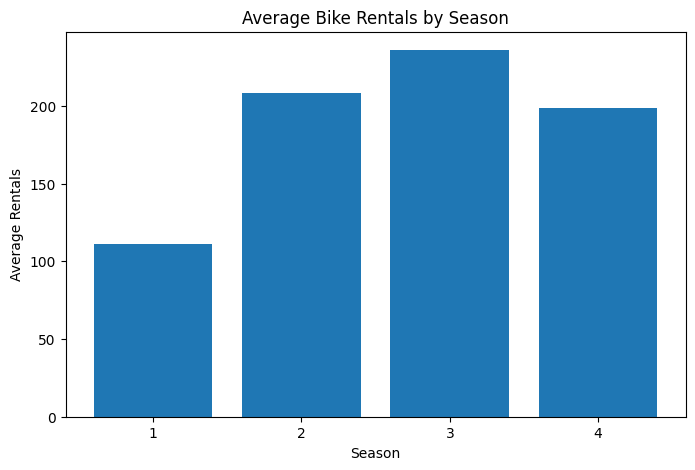

,cnt
season,
1,111.114569
2,208.344069
3,236.016237
4,198.868856


In [88]:
season_demand = df.groupby("season")["cnt"].mean()

plt.figure(figsize=(8, 5))

plt.bar(season_demand.index.astype(str),season_demand.values)

plt.xlabel("Season")
plt.ylabel("Average Rentals")
plt.title("Average Bike Rentals by Season")

plt.show()

season_demand

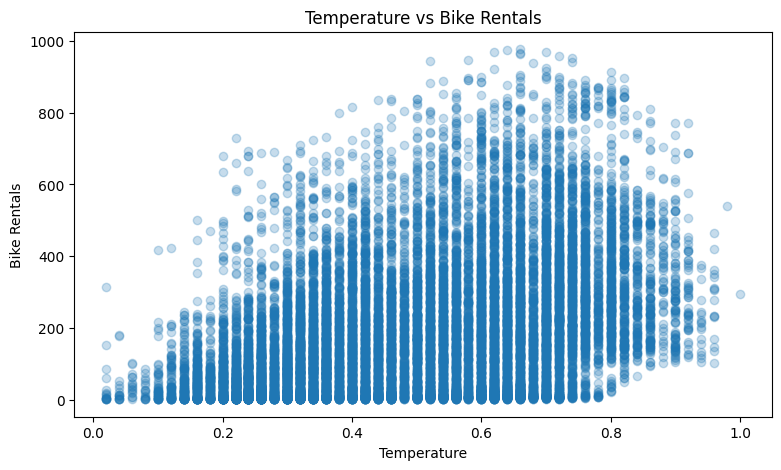

In [89]:
plt.figure(figsize=(9, 5))

plt.scatter(df["temp"],df["cnt"],alpha=0.25)

plt.xlabel("Temperature")
plt.ylabel("Bike Rentals")
plt.title("Temperature vs Bike Rentals")

plt.show()

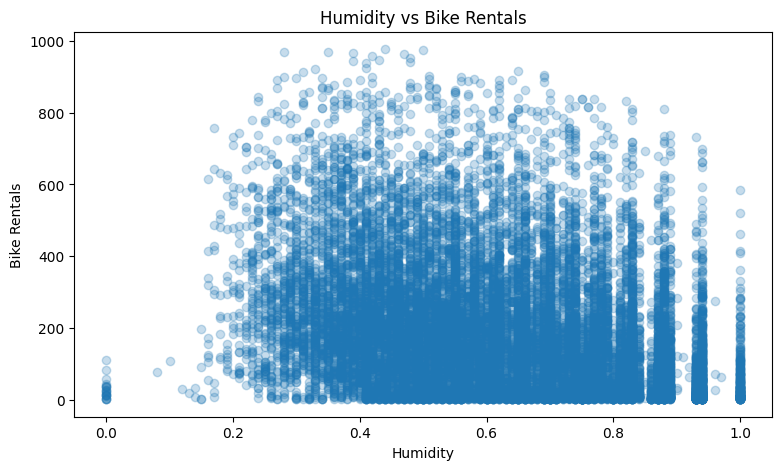

In [90]:
plt.figure(figsize=(9, 5))

plt.scatter(df["hum"],df["cnt"],alpha=0.25)

plt.xlabel("Humidity")
plt.ylabel("Bike Rentals")
plt.title("Humidity vs Bike Rentals")

plt.show()

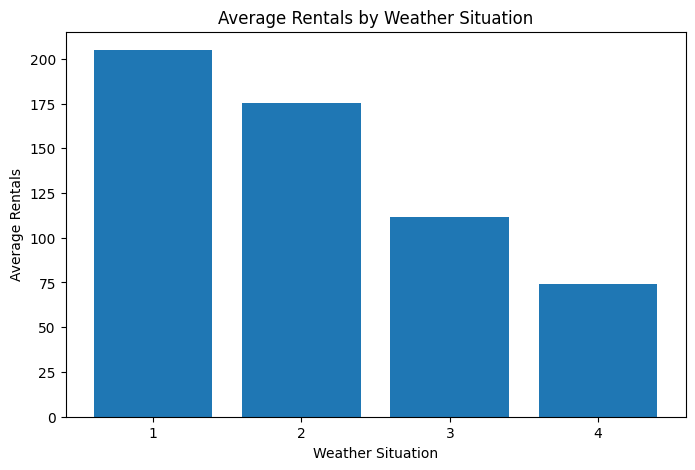

,cnt
weathersit,
1,204.869272
2,175.165493
3,111.579281
4,74.333333


In [91]:
weather_demand = df.groupby("weathersit")["cnt"].mean()

plt.figure(figsize=(8, 5))

plt.bar(weather_demand.index.astype(str),weather_demand.values)

plt.xlabel("Weather Situation")
plt.ylabel("Average Rentals")
plt.title("Average Rentals by Weather Situation")

plt.show()

weather_demand

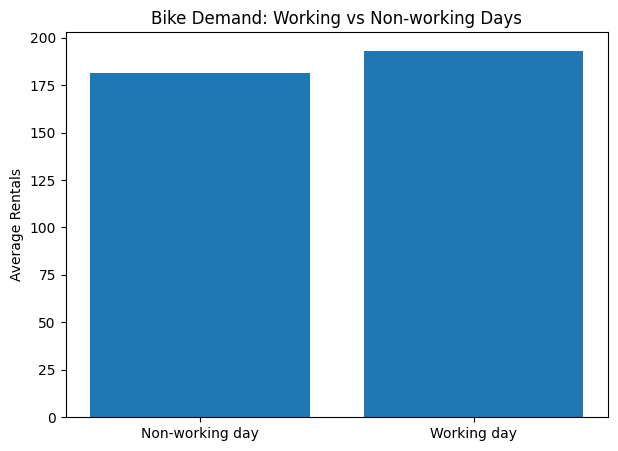

,cnt
workingday,
0,181.405332
1,193.207754


In [92]:
working_demand = df.groupby("workingday")["cnt"].mean()

plt.figure(figsize=(7, 5))

plt.bar(["Non-working day", "Working day"],working_demand.values)

plt.ylabel("Average Rentals")
plt.title("Bike Demand: Working vs Non-working Days")

plt.show()

working_demand

In [93]:
numeric_data = df.select_dtypes(include=np.number)
correlations = numeric_data.corr()["cnt"].sort_values(ascending=False)
correlations

,cnt
cnt,1.000000
registered,0.972151
casual,0.694564
temp,0.404772
atemp,0.400929
hr,0.394071
instant,0.278379
yr,0.250495
season,0.178056
mnth,0.120638


In [94]:
drop_columns = ["cnt","casual","registered", "instant", "dteday"]
X = df.drop(columns=drop_columns)
y = df["cnt"]

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFeatures:")
print(X.columns.tolist())

X shape: (17379, 12)
y shape: (17379,)

Features:
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']


In [95]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 13903
Testing samples: 3476


In [96]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [97]:
linear_model = LinearRegression()

linear_model.fit(X_train_scaled, y_train)

y_pred_linear = linear_model.predict(X_test_scaled)

linear_mae = mean_absolute_error(y_test, y_pred_linear)
linear_mse = mean_squared_error(y_test, y_pred_linear)
linear_rmse = np.sqrt(linear_mse)
linear_r2 = r2_score(y_test, y_pred_linear)

print("Linear Regression")
print("MAE:", linear_mae)
print("MSE:", linear_mse)
print("RMSE:", linear_rmse)
print("R2:", linear_r2)

Linear Regression
MAE: 104.80335089554426
MSE: 19379.82836765172
RMSE: 139.21145199893476
R2: 0.38798115831391333


In [98]:
k_values = [1, 3, 5, 7, 9, 11, 15, 20]

knn_scores = []

for k in k_values:

    knn_model = KNeighborsRegressor(n_neighbors=k)

    knn_model.fit(X_train_scaled, y_train)

    y_pred_knn = knn_model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred_knn)

    knn_scores.append(mae)

    print("K =", k, "MAE =", mae)

K = 1 MAE = 75.74165707710011
K = 3 MAE = 68.82489451476793
K = 5 MAE = 70.53245109321058
K = 7 MAE = 72.20812099293113
K = 9 MAE = 73.77186421173764
K = 11 MAE = 74.48807406632493
K = 15 MAE = 77.12897967011891
K = 20 MAE = 79.28888089758344


In [99]:
best_k = k_values[np.argmin(knn_scores)]

print("Best K:", best_k)
print("Best MAE:", min(knn_scores))

Best K: 3
Best MAE: 68.82489451476793


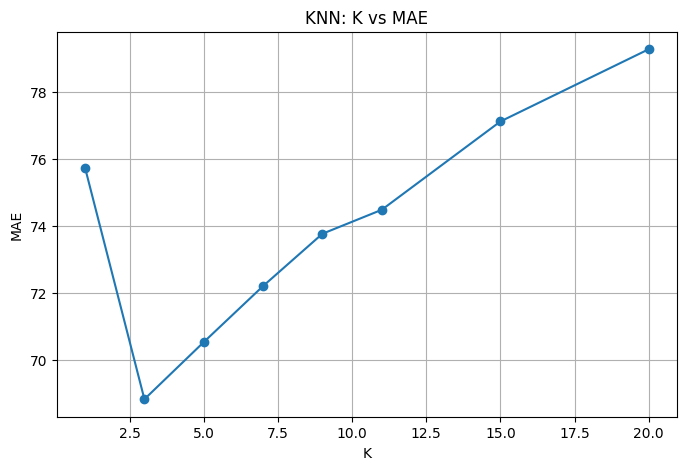

In [100]:
plt.figure(figsize=(8, 5))

plt.plot(k_values,knn_scores,marker="o")

plt.xlabel("K")
plt.ylabel("MAE")
plt.title("KNN: K vs MAE")

plt.grid(True)

plt.show()

In [101]:
knn_model = KNeighborsRegressor(n_neighbors=best_k)

knn_model.fit(X_train_scaled,y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

knn_mae = mean_absolute_error(y_test,y_pred_knn)

knn_mse = mean_squared_error(y_test,y_pred_knn)

knn_rmse = np.sqrt(knn_mse)

knn_r2 = r2_score(y_test,y_pred_knn)

print("KNN Regression")
print("Best K:", best_k)
print("MAE:", knn_mae)
print("MSE:", knn_mse)
print("RMSE:", knn_rmse)
print("R2:", knn_r2)

KNN Regression
Best K: 3
MAE: 68.82489451476793
MSE: 11246.388441375784
RMSE: 106.04899076076012
R2: 0.6448368119435197


In [102]:
depth_values = [3, 5, 8, 10, 15, 20]

tree_scores = []

for depth in depth_values:

    tree_model = DecisionTreeRegressor(max_depth=depth,random_state=42)

    tree_model.fit(X_train,y_train)

    y_pred_tree = tree_model.predict(X_test)

    mae = mean_absolute_error(y_test,y_pred_tree)

    tree_scores.append(mae)

    print("Max Depth =",depth,"MAE =",mae)

Max Depth = 3 MAE = 89.82386451877731
Max Depth = 5 MAE = 70.24142047070586
Max Depth = 8 MAE = 45.469690386777714
Max Depth = 10 MAE = 35.707824765118346
Max Depth = 15 MAE = 33.4204241086192
Max Depth = 20 MAE = 34.239204627355306


In [103]:
best_depth = depth_values[np.argmin(tree_scores)]

print("Best Max Depth:", best_depth)
print("Best MAE:", min(tree_scores))

Best Max Depth: 15
Best MAE: 33.4204241086192


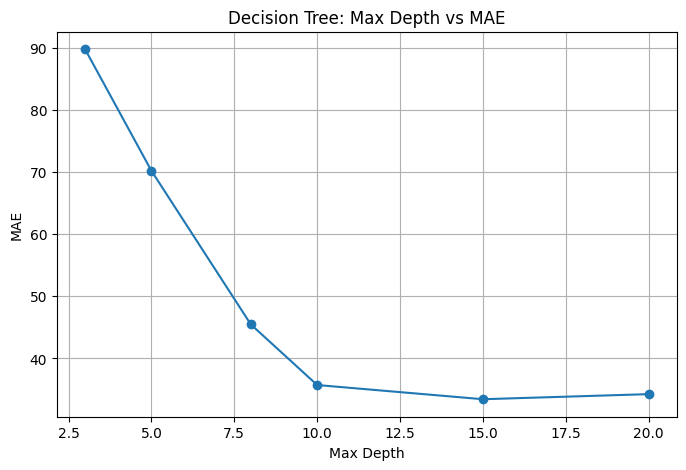

In [104]:
plt.figure(figsize=(8, 5))

plt.plot(depth_values,tree_scores,marker="o")

plt.xlabel("Max Depth")
plt.ylabel("MAE")
plt.title("Decision Tree: Max Depth vs MAE")

plt.grid(True)

plt.show()

In [105]:
tree_model = DecisionTreeRegressor(max_depth=best_depth,random_state=42)

tree_model.fit(X_train,y_train)

y_pred_tree = tree_model.predict(X_test)

tree_mae = mean_absolute_error(y_test,y_pred_tree)

tree_mse = mean_squared_error(y_test,y_pred_tree)

tree_rmse = np.sqrt(tree_mse)

tree_r2 = r2_score(y_test,y_pred_tree)

print("Decision Tree Regression")
print("Best Max Depth:", best_depth)
print("MAE:", tree_mae)
print("MSE:", tree_mse)
print("RMSE:", tree_rmse)
print("R2:", tree_r2)

Decision Tree Regression
Best Max Depth: 15
MAE: 33.4204241086192
MSE: 3345.218696407094
RMSE: 57.83786559345957
R2: 0.8943573269627574


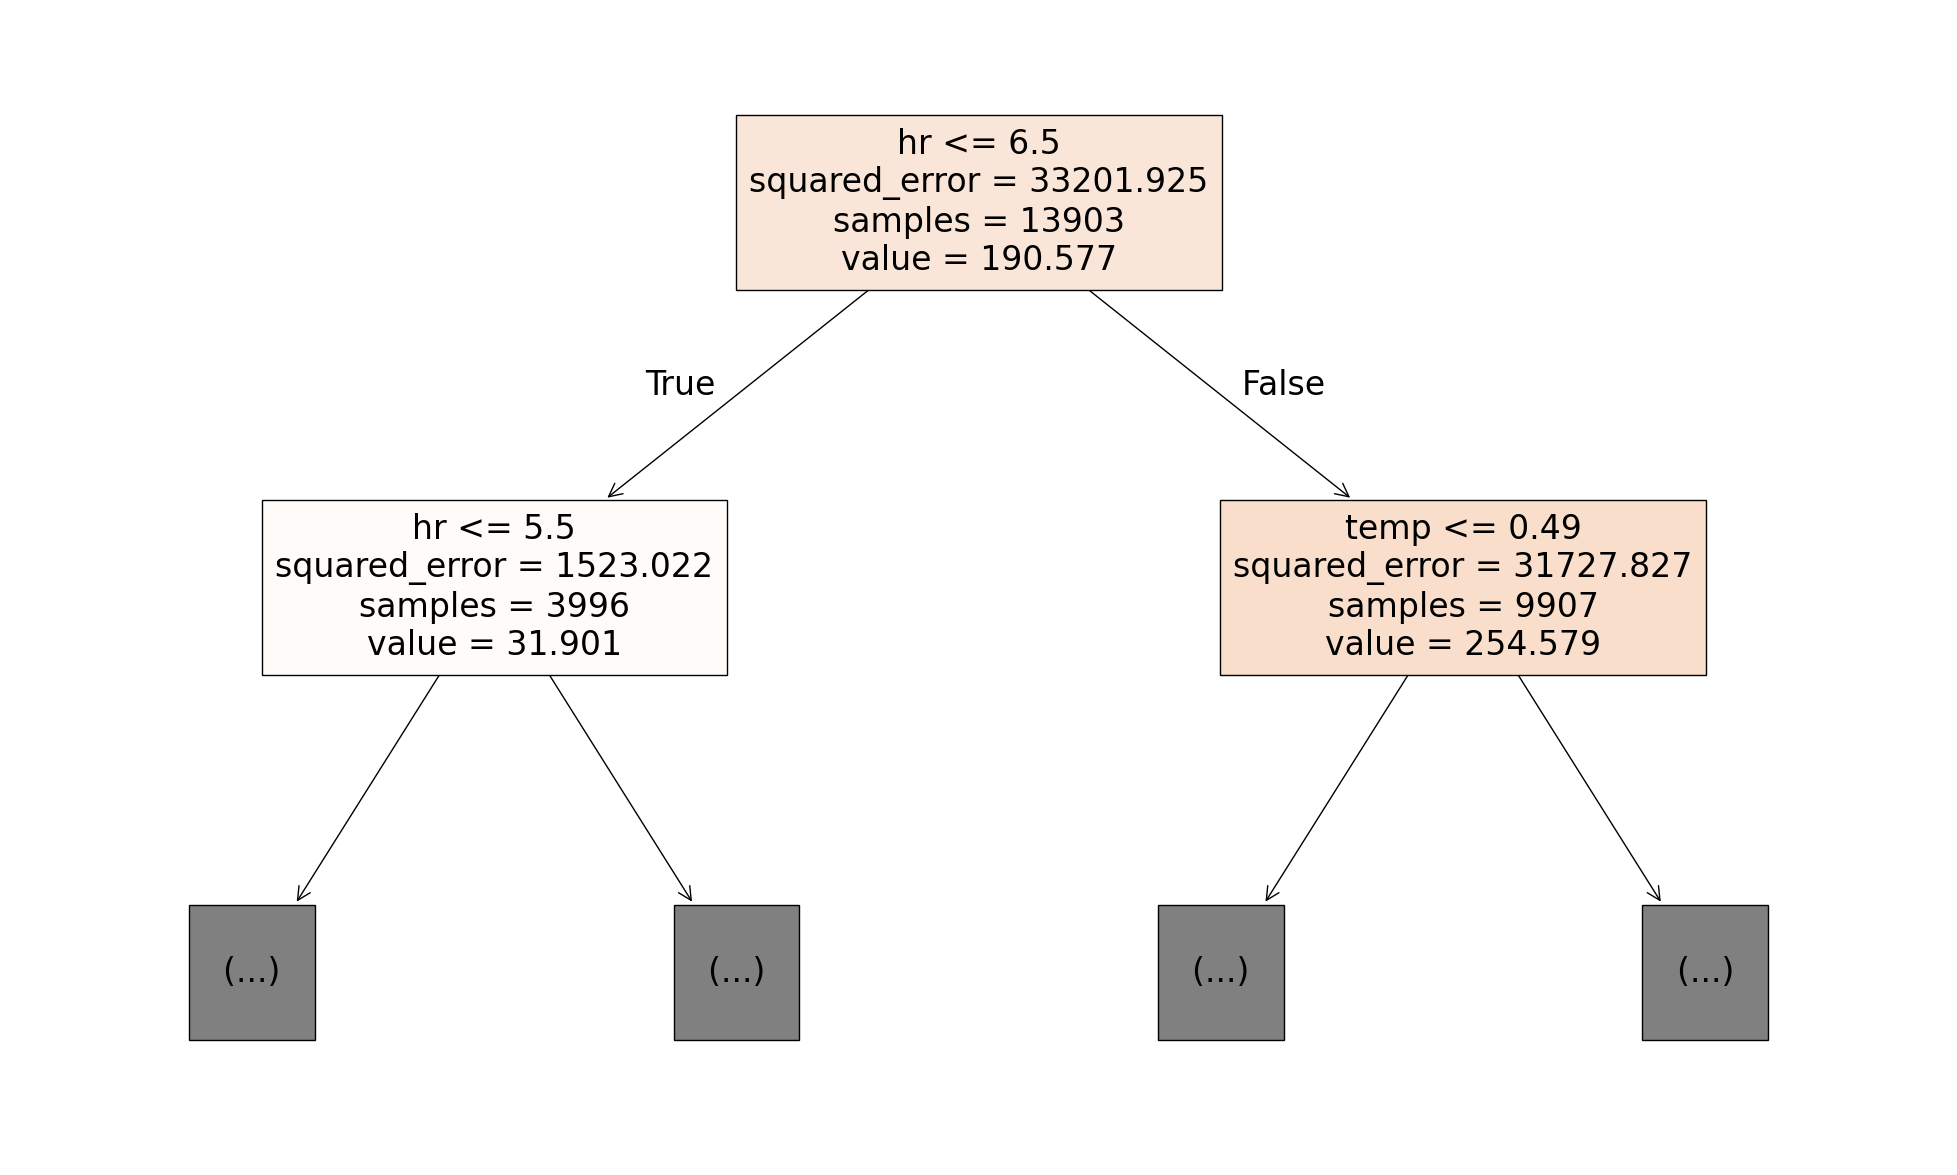

15


In [106]:
from sklearn.tree import plot_tree

plt.figure(figsize=(25, 15))

plot_tree(tree_model,feature_names=X.columns,max_depth=1,filled=True)

plt.show()
print(tree_model.get_depth())

In [107]:
results = pd.DataFrame({
    "Model": ["Linear Regression","KNN Regression","Decision Tree Regression"],

    "MAE": [linear_mae,knn_mae,tree_mae],

    "MSE": [linear_mse,knn_mse,tree_mse],

    "RMSE": [linear_rmse,knn_rmse,tree_rmse],

    "R2": [linear_r2,knn_r2,tree_r2]
})

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,104.803351,19379.828368,139.211452,0.387981
1,KNN Regression,68.824895,11246.388441,106.048991,0.644837
2,Decision Tree Regression,33.420424,3345.218696,57.837866,0.894357


In [108]:
results.sort_values(by="MAE")

,Model,MAE,MSE,RMSE,R2
2,Decision Tree Regression,33.420424,3345.218696,57.837866,0.894357
1,KNN Regression,68.824895,11246.388441,106.048991,0.644837
0,Linear Regression,104.803351,19379.828368,139.211452,0.387981


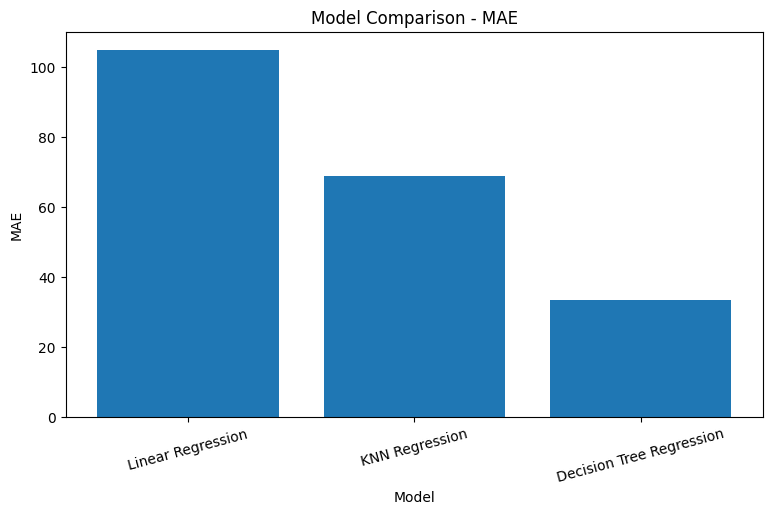

In [109]:
plt.figure(figsize=(9, 5))

plt.bar(results["Model"],results["MAE"])

plt.xlabel("Model")
plt.ylabel("MAE")
plt.title("Model Comparison - MAE")

plt.show()

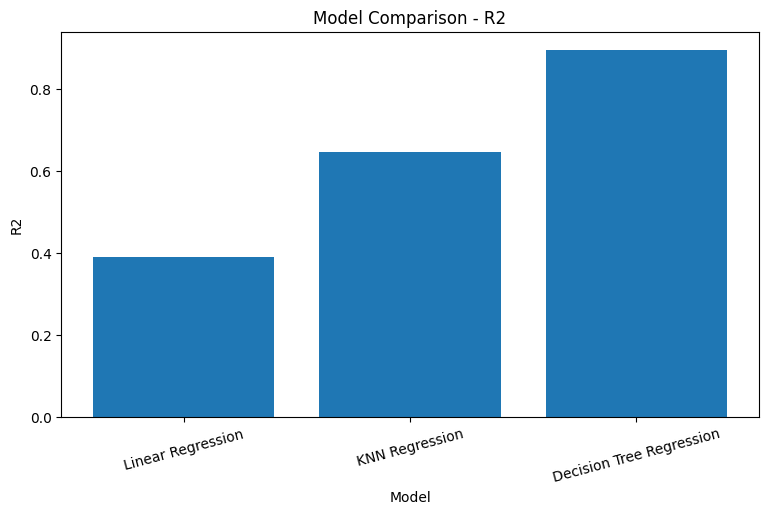

In [123]:
plt.figure(figsize=(9, 5))

plt.bar(results["Model"],results["R2"])

plt.xlabel("Model")
plt.ylabel("R2")
plt.title("Model Comparison - R2")

plt.show()

In [111]:
feature_importance = pd.DataFrame(tree_model.feature_importances_,index=X.columns,columns=["importance"])
feature_importance = feature_importance.sort_values(by="importance",ascending=False)
feature_importance

,importance
hr,0.617409
temp,0.114823
yr,0.081759
workingday,0.062675
hum,0.025636
season,0.023853
atemp,0.020015
weathersit,0.017168
mnth,0.015363
weekday,0.010415


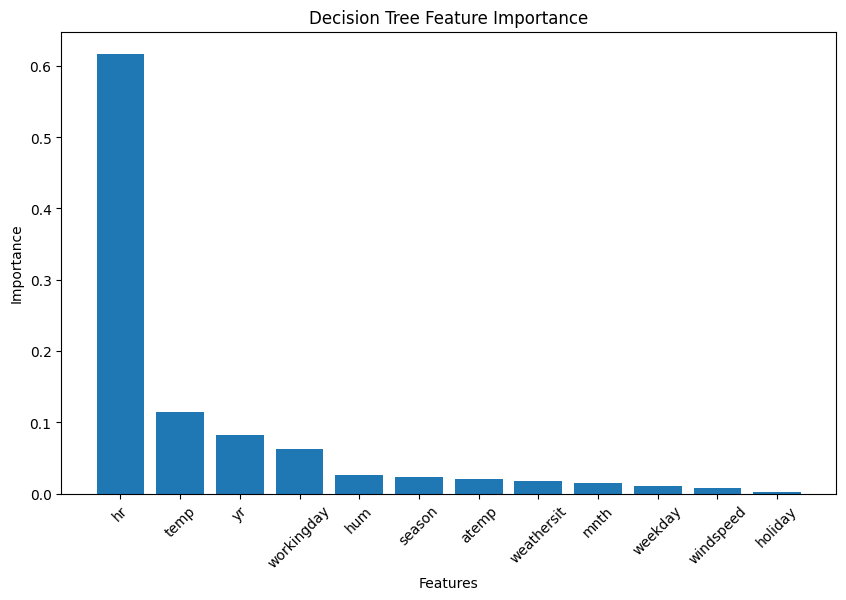

In [125]:
plt.figure(figsize=(10, 6))

plt.bar(feature_importance.index,feature_importance["importance"])

plt.xlabel("Features")
plt.ylabel("Importance")
plt.title("Decision Tree Feature Importance")

plt.xticks(rotation=45)

plt.show()

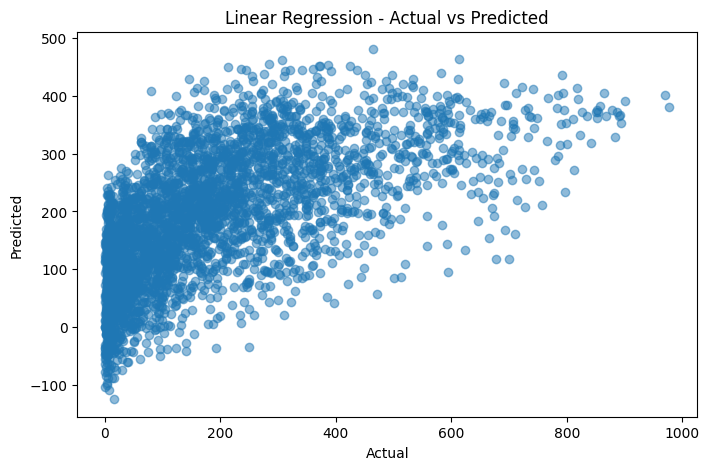

In [113]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test,y_pred_linear,alpha=0.5)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Linear Regression - Actual vs Predicted")

plt.show()

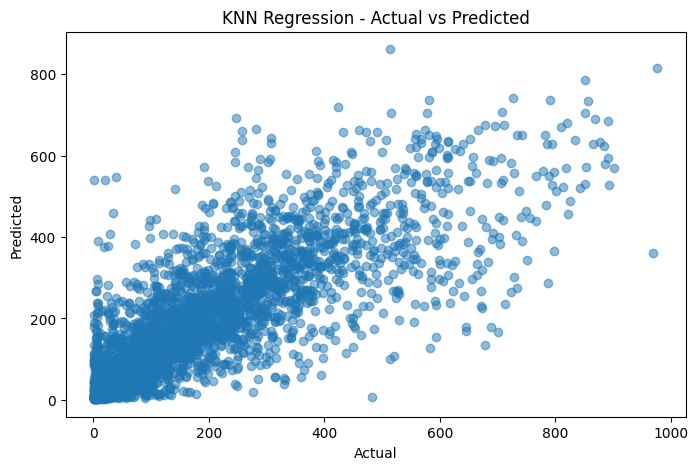

In [114]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test,y_pred_knn,alpha=0.5)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("KNN Regression - Actual vs Predicted")

plt.show()

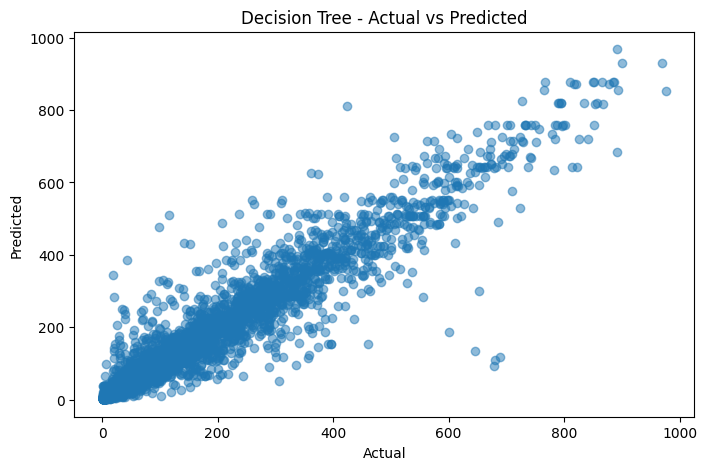

In [115]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test,y_pred_tree,alpha=0.5)

plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Decision Tree - Actual vs Predicted")

plt.show()

In [116]:
new_data = pd.DataFrame({
    "season": [2],
    "yr": [1],
    "mnth": [6],
    "hr": [18],
    "holiday": [0],
    "weekday": [2],
    "workingday": [1],
    "weathersit": [1],
    "temp": [0.60],
    "atemp": [0.58],
    "hum": [0.55],
    "windspeed": [0.20]
})

new_data

,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed
0,2,1,6,18,0,2,1,1,0.6,0.58,0.55,0.2


In [117]:
new_data_scaled = scaler.transform(new_data)

linear_prediction = linear_model.predict(new_data_scaled)

print("Linear Regression Prediction:",linear_prediction[0])

Linear Regression Prediction: 319.4717212742888


In [118]:
knn_prediction = knn_model.predict(new_data_scaled)

print("KNN Prediction:",knn_prediction[0])

KNN Prediction: 421.0


In [119]:
tree_prediction = tree_model.predict(new_data)

print("Decision Tree Prediction:",tree_prediction[0])

Decision Tree Prediction: 733.7333333333333


In [120]:
results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,104.803351,19379.828368,139.211452,0.387981
1,KNN Regression,68.824895,11246.388441,106.048991,0.644837
2,Decision Tree Regression,33.420424,3345.218696,57.837866,0.894357


In [121]:
print("Lowest MAE:")
print(results.loc[results["MAE"].idxmin()])

Lowest MAE:
Model    Decision Tree Regression
MAE                     33.420424
MSE                   3345.218696
RMSE                    57.837866
R2                       0.894357
Name: 2, dtype: object
